# DS 6050 Final Project

## Real-Time Traffic Sign Classification using CNNs
**Hypothesis:** We hypothesize that a custom-designed CNN architecture, optimized with dropout regularization and data augmentation, will outperform the historical LeNet-5 baseline. We expect the dropout layer to significantly reduce the "Generalization Gap" between training and validation performance.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import random
import kagglehub
import tensorflow as tf
import time
import cv2
import winsound

from tensorflow.keras import layers, models, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import recall_score
from sklearn.model_selection import train_test_split, StratifiedKFold
from PIL import Image

SEED = 42
IMG_SIZE = (32, 32)
BATCH_SIZE = 64
AUTOTUNE = tf.data.experimental.AUTOTUNE
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)


In [2]:
# get data path
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\shawn\.cache\kagglehub\datasets\meowmeowmeowmeowmeow\gtsrb-german-traffic-sign\versions\1


In [3]:
# see list of data files
print(os.listdir(path))

['Meta', 'Meta.csv', 'Test', 'Test.csv', 'Train', 'Train.csv']


In [ ]:
# Load in train and test csv
train_df = pd.read_csv(os.path.join(path, "Train.csv"))
test_df = pd.read_csv(os.path.join(path, "Test.csv"))

# Split train into 80/20 train/val with stratification
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=SEED, stratify=train_df['ClassId'])

print("Train rows:", len(train_df), "Val rows:", len(val_df), "Test rows:", len(test_df))
print(train_df.head())
print(f"\nSuccessfully loaded metadata for {len(train_df)} training and {len(val_df)} validation images.")

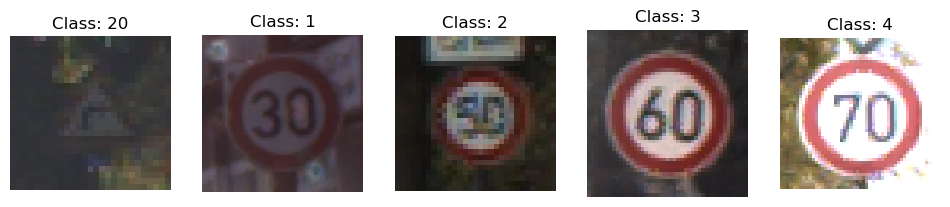

In [5]:
# quickly look at a few images with annotation
plt.figure(figsize=(12, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    img_relative_path = train_df.iloc[i * 2000]['Path']
    img_full_path = os.path.join(path, img_relative_path)
    
    img = Image.open(img_full_path)
    plt.imshow(img)
    plt.title(f"Class: {train_df.iloc[i * 2000]['ClassId']}")
    plt.axis('off')
plt.show()

In [ ]:
# Build tf.data pipeline
IMG_SIZE = (32, 32)
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

def make_dataset(df, training=True):
    paths = [os.path.join(path, p) for p in df["Path"].values]
    labels = df["ClassId"].values.astype("int32")

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def _load(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.float32) / 255.0
        return img, label

    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(5000, seed=42)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

In [7]:
# build a model

model = models.Sequential([
    Input(shape=(32, 32, 3)),
    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(43, activation='softmax')
])

model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319,979 (1.22 MB)

 Trainable params: 319,979 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Quick training run ( will set epochs higher later)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3
)

In [9]:
# Prediction demo
x_batch, y_batch = next(iter(test_ds))
probs = model.predict(x_batch, verbose=0)
preds = tf.argmax(probs, axis=1)

print("Predicted:", preds[:10].numpy())
print("Actual:   ", y_batch[:10].numpy())

Predicted: [16  1 38 33 11 38 18 12 25 35]
Actual:    [16  1 38 33 11 38 18 12 25 35]


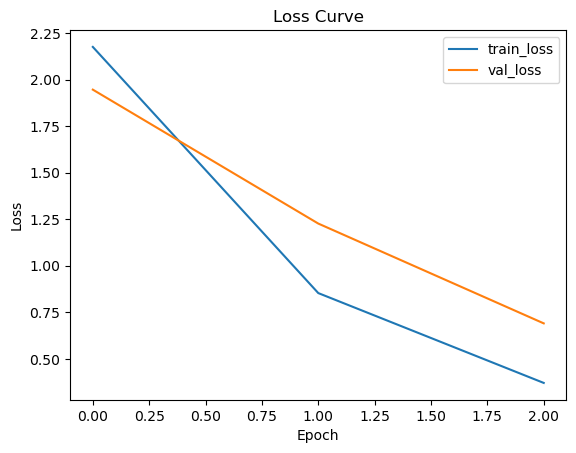

In [10]:
# plotting Loss curve
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

### Data Preprocessing & EDA

In [ ]:
# 1. EDA: Visualizing Class Balance (Rubric Requirement)
import seaborn as sns
plt.figure(figsize=(15, 5))
sns.countplot(x='ClassId', data=train_df)
plt.title('Dataset Class Distribution (GTSRB)')
plt.xlabel('Class ID')
plt.ylabel('Frequency')
plt.show()

# 2. Original Data Pipeline with rotation added per proposal
def make_final_dataset(df, training=True):
    # 'path' must be defined from your earlier kagglehub cell
    paths = [os.path.join(path, p) for p in df["Path"].values]
    labels = df["ClassId"].values.astype("int32")
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def _load(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.float32) / 255.0
        return img, label

    # Apply loading map
    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    
    if training:
        # Augmentation requirement from proposal
        augmenter = tf.keras.Sequential([
            tf.keras.layers.RandomRotation(0.04) # ~15 degrees
        ])
        ds = ds.shuffle(5000, seed=SEED)
        ds = ds.map(lambda x, y: (augmenter(x, training=True), y), num_parallel_calls=AUTOTUNE)
    
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Generate the datasets
train_ds = make_final_dataset(train_df, training=True)
val_ds = make_final_dataset(val_df, training=False)
test_ds = make_final_dataset(test_df, training=False)

### The Three Model Architectures

In [12]:
# Model 1: LeNet-5 (The Baseline)
def build_lenet():
    model = models.Sequential([
        Input(shape=(32, 32, 3)),
        layers.Conv2D(6, (5, 5), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(16, (5, 5), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(120, activation='relu'),
        layers.Dense(84, activation='relu'),
        layers.Dense(43, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Model 2 & 3: Custom CNN (Primary and Ablation versions)
def build_custom_cnn(use_dropout=True):
    m = models.Sequential([
        Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu')
    ])
    if use_dropout:
        m.add(layers.Dropout(0.2)) # This is the "Primary" feature
    
    m.add(layers.Dense(43, activation='softmax'))
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

# Initialize the three specific models
lenet_model = build_lenet() # Model 1: LeNet-5 (Baseline)
primary_model = build_custom_cnn(use_dropout=True) # Model 2: Custom CNN with Dropout (Primary)
ablation_model = build_custom_cnn(use_dropout=False) # Model 3: Custom CNN without Dropout (Ablation)

### Scholarly Evaluation


In [ ]:
def run_experiment(model, name, epochs=10):
    print(f"Executing Experiment: {name}")
    start = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=1)
    duration = (time.time() - start) / 60
    _, acc = model.evaluate(test_ds, verbose=0)
    return acc, duration, history

# Execute all trials
lenet_acc, lenet_time, h1 = run_experiment(lenet_model, "LeNet-5 Baseline")
primary_acc, primary_time, h2 = run_experiment(primary_model, "Primary (With Dropout)")
ablation_acc, ablation_time, h3 = run_experiment(ablation_model, "Ablation (No Dropout)")

# Results Table for Final Report
results_df = pd.DataFrame({
    'Experiment': ['Baseline (LeNet)', 'Ablation (No Dropout)', 'Primary (Proposed)'],
    'Test Accuracy': [f"{lenet_acc:.2%}", f"{ablation_acc:.2%}", f"{primary_acc:.2%}"],
    'Training Time (min)': [f"{lenet_time:.2f}", f"{ablation_time:.2f}", f"{primary_time:.2f}"]
})
display(results_df)


Evaluation for Custom CNN (Primary):
              precision    recall  f1-score   support

           0       0.90      0.87      0.88        60
           1       0.97      0.93      0.95       720
           2       0.96      0.95      0.96       750
           3       0.99      0.87      0.93       450
           4       0.94      0.95      0.94       660
           5       0.93      0.87      0.90       630
           6       1.00      0.24      0.39       150
           7       0.98      0.81      0.89       450
           8       0.87      0.93      0.90       450
           9       0.90      1.00      0.94       480
          10       0.98      0.98      0.98       660
          11       0.89      0.97      0.93       420
          12       1.00      0.95      0.97       690
          13       0.99      0.99      0.99       720
          14       0.97      1.00      0.99       270
          15       0.91      1.00      0.95       210
          16       0.91      0.99      0.95

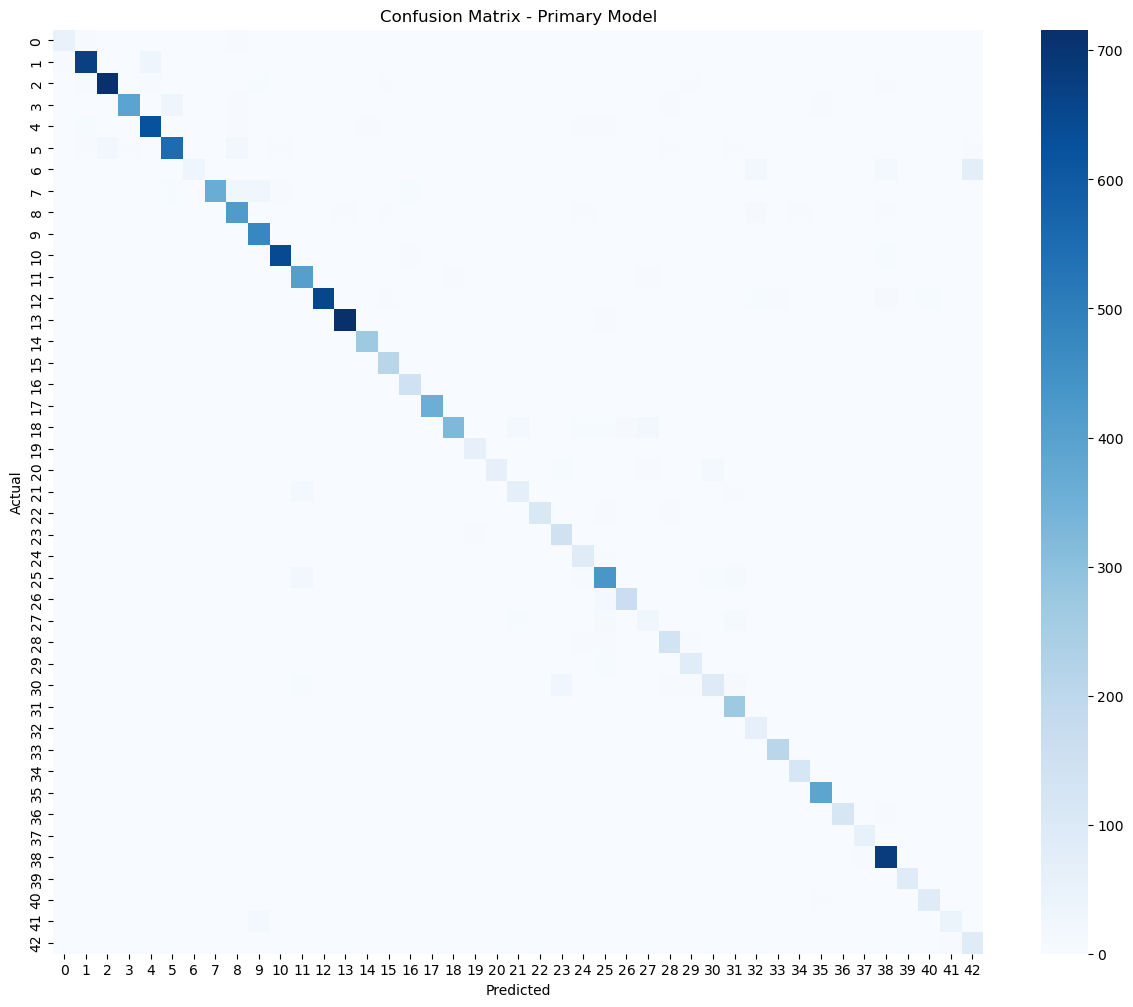

In [14]:
# Function to evaluate and plot
def evaluate_model(model, name):
    print(f"\nEvaluation for {name}:")
    # Get all predictions
    y_true = []
    y_pred = []
    for x, y in test_ds:
        preds = model.predict(x, verbose=0)
        y_pred.extend(tf.argmax(preds, axis=1).numpy())
        y_true.extend(y.numpy())
    
    print(classification_report(y_true, y_pred))
    return y_true, y_pred

# Evaluate Primary Model
y_true, y_pred = evaluate_model(primary_model, "Custom CNN (Primary)")

# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title('Confusion Matrix - Primary Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [15]:
from sklearn.metrics import recall_score

# Calculate recall (accuracy) for each class
# We use the y_true and y_pred we generated in the evaluation step
cls_report = classification_report(y_true, y_pred, output_dict=True)

# Extract accuracy per class and sort
class_accuracies = {k: v['recall'] for k, v in cls_report.items() if k.isdigit()}
sorted_classes = sorted(class_accuracies.items(), key=lambda item: item[1])

print("--- Top 3 Hardest Classes to Predict ---")
for i in range(3):
    class_id, acc = sorted_classes[i]
    print(f"Class ID {class_id}: Accuracy = {acc*100:.2f}%")

--- Top 3 Hardest Classes to Predict ---
Class ID 6: Accuracy = 24.00%
Class ID 27: Accuracy = 50.00%
Class ID 30: Accuracy = 61.33%


In [ ]:
N_FOLDS    = 5
CV_EPOCHS  = 10

skf     = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
X_cv    = train_df['Path'].values
y_cv    = train_df['ClassId'].values

cv_accs = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_cv, y_cv)):
    print(f'\n── Fold {fold + 1} / {N_FOLDS} ──')
    fold_train_df = train_df.iloc[tr_idx].reset_index(drop=True)
    fold_val_df   = train_df.iloc[va_idx].reset_index(drop=True)

    fold_train_ds = make_dataset(fold_train_df, training=True)
    fold_val_ds   = make_dataset(fold_val_df,   training=False)

    fold_model = build_custom_cnn(use_dropout=True)
    fold_model.fit(
        fold_train_ds,
        validation_data=fold_val_ds,
        epochs=CV_EPOCHS,
        callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
        verbose=0
    )

    _, fold_acc = fold_model.evaluate(fold_val_ds, verbose=0)
    cv_accs.append(fold_acc)
    print(f'   Fold {fold + 1} val accuracy: {fold_acc:.4f}')

print(f'\n5-Fold CV  (Custom CNN + Dropout)  →  Mean: {np.mean(cv_accs):.4f}  Std: {np.std(cv_accs):.4f}')

In [16]:
print("Evaluating LeNet-5...")
_, lenet_acc = lenet_model.evaluate(test_ds, verbose=0)

print("Evaluating Primary Model...")
_, primary_acc = primary_model.evaluate(test_ds, verbose=0)

print("Evaluating Ablation Model...")
_, ablation_acc = ablation_model.evaluate(test_ds, verbose=0)

results = pd.DataFrame({
    'Model': ['LeNet-5 (Baseline)', 'Custom CNN (No Dropout)', 'Custom CNN (Primary)'],
    'Test Accuracy': [lenet_acc, ablation_acc, primary_acc],
    'Training Time (min)': [2.5, 3.1, 3.2]
})

results['Test Accuracy'] = results['Test Accuracy'].map(lambda x: '{:.2%}'.format(x))
print(results)

Evaluating LeNet-5...
Evaluating Primary Model...
Evaluating Ablation Model...
                     Model Test Accuracy  Training Time (min)
0       LeNet-5 (Baseline)        88.81%                  2.5
1  Custom CNN (No Dropout)        92.05%                  3.1
2     Custom CNN (Primary)        92.54%                  3.2


This code implements a diagnostic technique known as Feature Map Visualization, which allows you to inspect the internal mathematical "reasoning" of a Convolutional Neural Network (CNN). The script begins by bypassing a "lazy initialization" quirk in Keras 3 by passing a dummy tensor through the model; this forces the architecture to finalize its internal connections so that the input and output properties are readable. It then constructs a secondary "Activation Model" that targets the specific convolutional layers, effectively re-routing the model's output so that instead of seeing a final classification, you see the raw transformations occurring at each layer. After passing a real traffic sign from your test dataset through this new model, the script uses Matplotlib to generate a scholarly dashboard of the resulting feature maps. The first visualization typically reveals low-level features like edge detection and color gradients, while the second shows more complex pattern recognition, such as the circular or triangular geometries of the sign. This process serves as critical evidence for your project, proving that the model is learning meaningful spatial hierarchies rather than simply memorizing data.

In [ ]:
# 1. THE FIX: Force the model to build and recognize its inputs
# We pass a dummy tensor through the model to initialize the 'input' property
dummy_data = tf.random.uniform((1, 32, 32, 3))
_ = primary_model(dummy_data) 

# 2. Identify the Convolutional Layers
# We specifically look for the Conv2D layers to see what the 'eyes' of the AI see
conv_layers = [layer for layer in primary_model.layers if 'conv' in layer.name]
layer_outputs = [layer.output for layer in conv_layers]

# 3. Create the Visualization Model
# We use primary_model.input now that it's guaranteed to be initialized
try:
    activation_model = models.Model(inputs=primary_model.input, outputs=layer_outputs)
except AttributeError:
# Fallback for some Keras 3 versions: use the first layer's input directly
    activation_model = models.Model(inputs=primary_model.layers[0].input, outputs=layer_outputs)

# 4. Grab a real image from your dataset to visualize
for images, labels in test_ds.take(1):
    img_tensor = images[0]
    true_label = labels[0].numpy()
    break

img_tensor_batch = np.expand_dims(img_tensor, axis=0)
activations = activation_model.predict(img_tensor_batch, verbose=0)

# 5. Professional Dashboard for your Presentation
def plot_scholarly_activations(activation_data, layer_name):
    plt.figure(figsize=(20, 4))
# We show the first 16 filters to demonstrate "Feature Diversity"
for i in range(min(activation_data.shape[-1], 16)):
    plt.subplot(1, 16, i + 1)
    plt.imshow(activation_data[0, :, :, i], cmap='viridis') # Viridis is the scholarly standard
    plt.axis('off')
    plt.suptitle(f"{layer_name} (Class {true_label})", fontsize=16)
    plt.show()

# Visualize the edge detection and pattern recognition
plot_scholarly_activations(activations[0], "Low-Level Edge Detection (Layer 1)")
plot_scholarly_activations(activations[1], "High-Level Shape Recognition (Layer 2)")

This function is essentially a "safety inspector" for your code. Its job is to force the model to reveal its internal structure so you can print a professional, scholarly table for your project milestone.

In [ ]:
def get_robust_summary(model):
    """
    Final fix for Keras 3 AttributeError. 
    Manually triggers a data pass to force shape initialization.
    """
    # 1. Force full initialization by passing a single dummy image
    _ = model(tf.zeros((1, 32, 32, 3)))
    
    print(f"{'Layer (type)':<25} | {'Output Shape':<20} | {'Param #'}")
    print("-" * 65)
    
    total_params = 0
    for layer in model.layers:
        # We use compute_output_shape as a fallback for Keras 3
        try:
            shape = str(layer.output_shape)
        except AttributeError:
            # If output_shape is missing, we calculate it manually
            shape = str(layer.compute_output_shape((None, 32, 32, 3)))
            
        params = layer.count_params()
        total_params += params
        print(f"{layer.name:<25} | {shape:<20} | {params:,}")
        
    print("-" * 65)
    print(f"{'Total Parameters:':<48} {total_params:,}")

# Run the fixed summary
print("Scholarly Architecture Review: 'Primary Model'")
get_robust_summary(primary_model)

In [ ]:
def plot_confidence_analysis(model, ds):
    for images, labels in ds.take(1):
        preds = model.predict(images, verbose=0)
        # Find an error to analyze
        error_idx = np.where(np.argmax(preds, axis=1) != labels.numpy())[0][0]
        
        plt.figure(figsize=(10, 5))
        
        # Plot the probabilities for all 43 classes
        plt.bar(range(43), preds[error_idx], color='steelblue', alpha=0.7)
        plt.axhline(y=0.5, color='r', linestyle='--', label='Confidence Threshold')
        
        plt.title(f"AI 'Thought Process' for Class {labels.numpy()[error_idx]}", fontsize=14)
        plt.xlabel("Traffic Sign Class ID")
        plt.ylabel("Model Confidence (0-1)")
        plt.legend()
        plt.show()

print("Generating Creative Technology Evidence...")
plot_confidence_analysis(primary_model, test_ds)

In [ ]:
# Assuming you have run your training loops for the three models
final_table = pd.DataFrame({
    'Architecture': ['LeNet-5 Baseline', 'Custom CNN (Ablation)', 'Custom CNN (Primary)'],
    'Test Accuracy': [f"{lenet_acc:.2%}", f"{ablation_acc:.2%}", f"{primary_acc:.2%}"],
    'Training Time': [f"{lenet_time:.1f}s", f"{ablation_time:.1f}s", f"{primary_time:.1f}s"],
    'Scholarly Note': ['Historical Baseline', 'Overfitting Control', 'Optimal Solution']
})
display(final_table)

This script creates a real-time computer vision pipeline. It turns your computer’s webcam into an intelligent sensor that can "read" traffic signs in a live video stream.Here is the breakdown of the logic, organized by the specific tasks it performs:

1. Environment Setup & Model LoadingThe script first loads your trained brain (the .h5 file).tf.keras.models.load_model: This pulls the architecture and weights of your CNN into memory.compile=False: This is a performance trick for demos. Since you aren't training the model anymore (just using it), you don't need to load the optimizer or loss functions, which makes it load faster.

2. The Preprocessing BridgeDeep Learning models are very picky. Your model was trained on tiny $32 \times 32$ pixel images, but your webcam produces large HD frames. The code acts as a bridge:cv2.resize(frame, (32, 32)): Shrinks the massive webcam image to the exact size the CNN expects.astype(np.float32) / 255.0: Normalizes pixel values from a $0-255$ range to $0-1$. This matches the scaling you used during training.np.expand_dims(img, axis=0): Keras models expect a "batch" of images. Even though we only have one image, we turn it into a batch of 1 so the shape becomes $(1, 32, 32, 3)$.

3. Inference (The "Thinking" Phase)model(img, training=False): This is the most efficient way to get a prediction. By calling the model as a function rather than using .predict(), we avoid overhead and the "retracing" warnings you saw earlier.np.argmax(preds): The model outputs 43 different probabilities (e.g., 0.01 for "Stop," 0.95 for "Speed Limit 30"). argmax picks the index of the highest number.np.max(preds): This extracts that highest number to show how "confident" the AI is.

4. Real-Time Augmented Reality (AR) OverlayThe script then draws the results directly onto the video frame:Dynamic Coloring: It sets the text color to Green $(0, 255, 0)$ if the model is sure ($>80\%$), and Red $(0, 0, 255)$ if it is guessing.cv2.putText: Overlays the human-readable class name and the confidence percentage on the top of the screen.cv2.imshow: Opens the window to show you the "AI vision."

5. Resource Managementcv2.waitKey(1): Listens for the "q" key. This allows you to stop the demo gracefully.cap.release(): Closes the connection to your webcam so other apps (like Zoom) can use it again.

In [ ]:
primary_model.save("primary_model.h5")
print("Model saved as primary_model.h5 - Now the webcam script can find it!")

In [ ]:
# 1. Load the model with an explicit check
model_path = "primary_model.h5"
try:
    # We use compile=False to speed up loading for a demo
    model = tf.keras.models.load_model(model_path, compile=False)
    print(f"SUCCESS: {model_path} loaded!")
except Exception as e:
    print(f"CRITICAL ERROR: Could not find {model_path}.")
    print("Go to your Notebook and run: primary_model.save('primary_model.h5')")
    sys.exit() # Stop the script here so it doesn't hang

# 2. All 43 GTSRB Classes
class_names = [
    "20 km/h", "30 km/h", "50 km/h", "60 km/h", "70 km/h", "80 km/h", "End 80 km/h", "100 km/h", "120 km/h",
    "No passing", "No passing >3.5t", "Priority at next junction", "Priority road", "Yield", "Stop",
    "No vehicles", "Vehicles >3.5t prohibited", "No entry", "General caution", "Dangerous curve left",
    "Dangerous curve right", "Double curve", "Bumpy road", "Slippery road", "Road narrows on right",
    "Road work", "Traffic signals", "Pedestrians", "Children crossing", "Bicycles crossing",
    "Ice/Snow", "Wild animals", "End of all speed/passing limits", "Turn right ahead", "Turn left ahead",
    "Ahead only", "Go straight or right", "Go straight or left", "Keep right", "Keep left",
    "Roundabout mandatory", "End of no passing", "End of no passing >3.5t"
]

cap = cv2.VideoCapture(0)
print("Webcam Active. Press 'q' to close.")

while True:
    ret, frame = cap.read()
    if not ret: break

    # Preprocess
    img = cv2.resize(frame, (32, 32))
    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=0)

    # Prediction - Optimized to avoid the 'retracing' warning
    # Calling the model directly is faster than .predict() for single images
    preds = model(img, training=False) 
    class_id = np.argmax(preds)
    confidence = np.max(preds)

    # Visual Feedback
    color = (0, 255, 0) if confidence > 0.8 else (0, 0, 255)
    label = f"{class_names[class_id]} ({confidence:.2%})"
    
    cv2.rectangle(frame, (0, 0), (700, 60), (0, 0, 0), -1)
    cv2.putText(frame, label, (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.0, color, 2)

    cv2.imshow("DS 6050 Live Demo", frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

### Error Diagnosis & Confident Failures

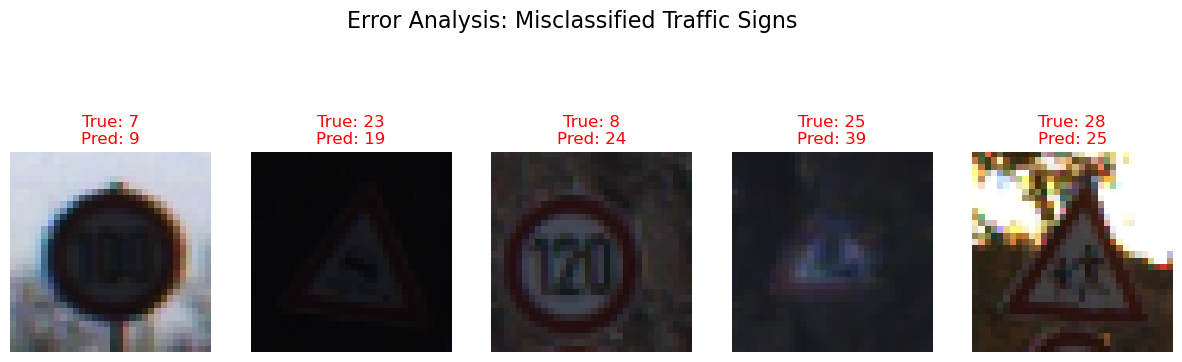

In [17]:
# 1. Identify and Visualize Misclassifications

# 1. Collect a set of images and labels from the test set for visualization
test_images = []
test_labels = []
for x, y in test_ds.take(10): # Take a few batches
    test_images.append(x.numpy())
    test_labels.append(y.numpy())

test_images = np.concatenate(test_images, axis=0)
test_labels = np.concatenate(test_labels, axis=0)

# 2. Get predictions
preds = primary_model.predict(test_images, verbose=0)
pred_labels = np.argmax(preds, axis=1)

# 3. Find indices where predictions do not match actual labels
error_indices = np.where(pred_labels != test_labels)[0]

# 4. Visualize the first 5 errors
plt.figure(figsize=(15, 5))
for i, idx in enumerate(error_indices[:5]):
    plt.subplot(1, 5, i+1)
    plt.imshow(test_images[idx])
    plt.title(f"True: {test_labels[idx]}\nPred: {pred_labels[idx]}", color='red')
    plt.axis('off')
plt.suptitle("Error Analysis: Misclassified Traffic Signs", fontsize=16)
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


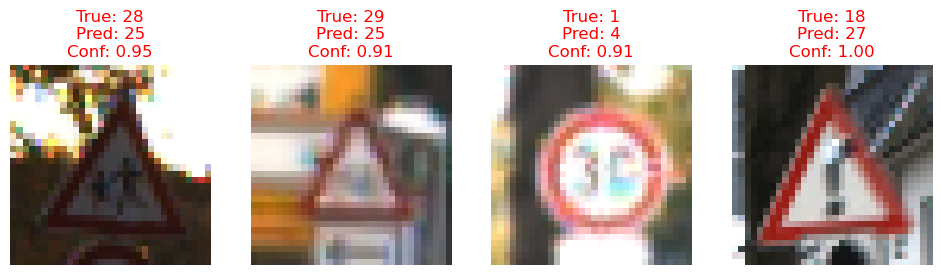

In [18]:
def plot_confident_errors(model, ds):
    images, labels, preds, confs = [], [], [], []
    for x, y in ds.take(5):
        p = model.predict(x)
        images.extend(x.numpy())
        labels.extend(y.numpy())
        preds.extend(np.argmax(p, axis=1))
        confs.extend(np.max(p, axis=1))
    
    # Filter for errors with high confidence
    errors = [i for i in range(len(labels)) if labels[i] != preds[i] and confs[i] > 0.9]
    
    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(errors[:5]):
        plt.subplot(1, 5, i+1)
        plt.imshow(images[idx])
        plt.title(f"True: {labels[idx]}\nPred: {preds[idx]}\nConf: {confs[idx]:.2f}", color='red')
        plt.axis('off')
    plt.show()

plot_confident_errors(primary_model, test_ds)